## Ejercicio 1: Evaluación de solicitud de crédito bancario

### Ficha PEAS

| Componente | Descripción |
| :--- | :--- |
| **Percepción (S)** | Variables de entrada: `ingreso_mensual` (S/), `monto_solicitado` (S/) y `tiene_historial_moroso` (booleano). |
| **Acciones (A)** | Resoluciones posibles: `"aprobar"`, `"aprobar con condiciones"` o `"rechazar"`. |
| **Entorno (E)** | Sistema digital de evaluación y análisis de riesgo crediticio bancario. |
| **Objetivo** | Evaluar automáticamente solicitudes de crédito clasificándolas según su nivel de riesgo para autorizar o denegar el préstamo. |
| **Medida de desempeño (P)** | Minimizar la tasa de morosidad e impagos y maximizar la colocación eficiente de créditos sostenibles. |

### Justificación de las reglas

Una elevada relación monto/ingreso refleja un sobreendeudamiento que compromete directamente la liquidez del cliente ante imprevistos. Registrar historial moroso demuestra antecedentes de incumplimiento de pago, lo que constituye un riesgo inaceptable para el banco y exige un rechazo automático. Definir un rango intermedio de aprobación condicional permite captar clientes de riesgo moderado bajo la exigencia de garantías o avales, protegiendo el capital de la entidad sin frenar el crecimiento comercial.

### Código

In [3]:
def agente_credito(ingreso_mensual, monto_solicitado, tiene_historial_moroso):
    """
    Evalúa solicitudes de crédito bancario según la relación monto/ingreso e historial moroso.
    Retorna una tupla: (accion, motivo)
    """
    if ingreso_mensual <= 0:
        return "rechazar", "El ingreso mensual debe ser mayor a cero."
    
    relacion = monto_solicitado / ingreso_mensual
    
    # Regla 1: Rechazo por historial moroso
    if tiene_historial_moroso:
        return "rechazar", f"Cliente registra historial moroso activo (relación monto/ingreso: {relacion:.2f})."
    
    # Regla 2: Evaluación por niveles de endeudamiento
    if relacion <= 0.30:
        return "aprobar", f"Capacidad de pago adecuada (relación monto/ingreso: {relacion:.2f} <= 0.30)."
    elif relacion <= 0.60:
        return "aprobar con condiciones", f"Endeudamiento moderado; requiere aval o garantía (relación monto/ingreso: {relacion:.2f})."
    else:
        return "rechazar", f"Monto solicitado excede la capacidad de endeudamiento (relación monto/ingreso: {relacion:.2f} > 0.60)."

### Simulación y pruebas

In [4]:
# 6 combinaciones de prueba (incluyendo casos límite en bordes de decisión)
casos_prueba = [
    # (ingreso_mensual, monto_solicitado, tiene_historial_moroso)
    (5000, 1000, False),  # Relación = 0.20 -> Aprobar
    (5000, 1500, False),  # Relación = 0.30 -> Borde exacto entre Aprobar y Condicional
    (5000, 2500, False),  # Relación = 0.50 -> Aprobar con condiciones
    (5000, 3000, False),  # Relación = 0.60 -> Borde exacto entre Condicional y Rechazar
    (5000, 4000, False),  # Relación = 0.80 -> Rechazar por monto excesivo
    (5000, 1000, True),   # Relación = 0.20 con Morosidad -> Rechazar por historial
]

print("=== EVALUACIÓN DE CASOS DE PRUEBA ===")
for i, (ingreso, monto, moroso) in enumerate(casos_prueba, 1):
    accion, motivo = agente_credito(ingreso, monto, moroso)
    print(f"Prueba {i} [Ingreso: S/{ingreso}, Monto: S/{monto}, Moroso: {moroso}]")
    print(f"  └─ Decisión: [{accion.upper()}] -> Motivo: {motivo}\n")

=== EVALUACIÓN DE CASOS DE PRUEBA ===
Prueba 1 [Ingreso: S/5000, Monto: S/1000, Moroso: False]
  └─ Decisión: [APROBAR] -> Motivo: Capacidad de pago adecuada (relación monto/ingreso: 0.20 <= 0.30).

Prueba 2 [Ingreso: S/5000, Monto: S/1500, Moroso: False]
  └─ Decisión: [APROBAR] -> Motivo: Capacidad de pago adecuada (relación monto/ingreso: 0.30 <= 0.30).

Prueba 3 [Ingreso: S/5000, Monto: S/2500, Moroso: False]
  └─ Decisión: [APROBAR CON CONDICIONES] -> Motivo: Endeudamiento moderado; requiere aval o garantía (relación monto/ingreso: 0.50).

Prueba 4 [Ingreso: S/5000, Monto: S/3000, Moroso: False]
  └─ Decisión: [APROBAR CON CONDICIONES] -> Motivo: Endeudamiento moderado; requiere aval o garantía (relación monto/ingreso: 0.60).

Prueba 5 [Ingreso: S/5000, Monto: S/4000, Moroso: False]
  └─ Decisión: [RECHAZAR] -> Motivo: Monto solicitado excede la capacidad de endeudamiento (relación monto/ingreso: 0.80 > 0.60).

Prueba 6 [Ingreso: S/5000, Monto: S/1000, Moroso: True]
  └─ Decisión:

### Visualización

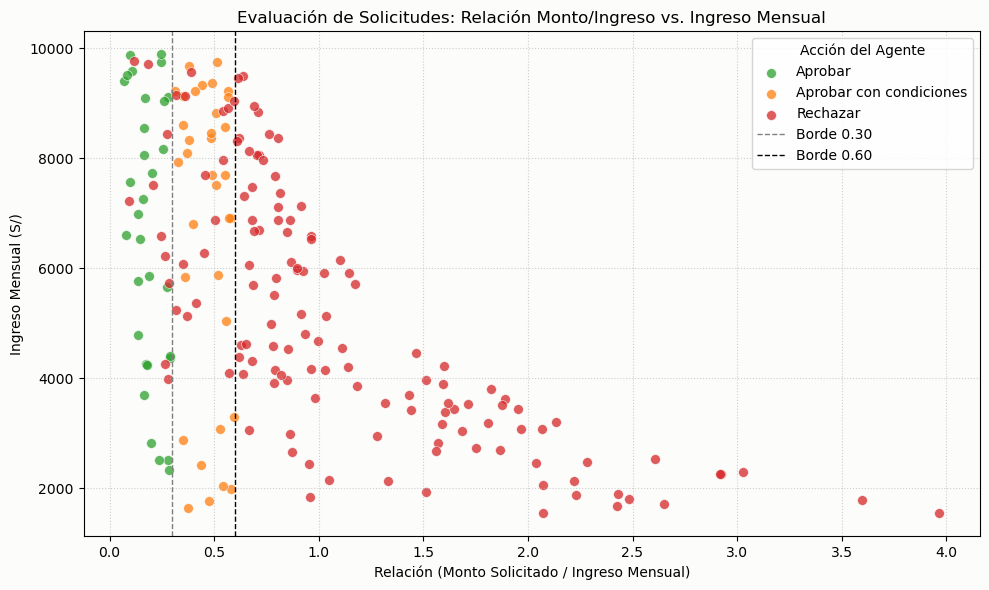

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Semilla de reproducibilidad
np.random.seed(42)
n_solicitudes = 200

# Generar 200 solicitudes aleatorias
ingresos = np.random.uniform(1500, 10000, n_solicitudes)
montos = np.random.uniform(500, 7000, n_solicitudes)
historiales = np.random.choice([True, False], size=n_solicitudes, p=[0.25, 0.75])

relaciones = montos / ingresos
acciones = []

# Evaluar cada caso con el agente
for ing, mon, hist in zip(ingresos, montos, historiales):
    accion, _ = agente_credito(ing, mon, hist)
    acciones.append(accion)

# Gráfica Scatter: relacion vs. ingreso_mensual
plt.figure(figsize=(10, 6), facecolor="#fcfcfb")
ax = plt.axes()
ax.set_facecolor("#fcfcfb")

colores = {
    "aprobar": "#2ca02c",                  # Verde
    "aprobar con condiciones": "#ff7f0e",  # Naranja
    "rechazar": "#d62728"                  # Rojo
}

for cat in ["aprobar", "aprobar con condiciones", "rechazar"]:
    indices = [i for i, a in enumerate(acciones) if a == cat]
    plt.scatter(
        relaciones[indices], ingresos[indices],
        c=colores[cat], label=cat.capitalize(),
        alpha=0.75, s=50, edgecolors="white", linewidths=0.5
    )

plt.axvline(x=0.30, color="gray", linestyle="--", linewidth=1, label="Borde 0.30")
plt.axvline(x=0.60, color="black", linestyle="--", linewidth=1, label="Borde 0.60")

plt.title("Evaluación de Solicitudes: Relación Monto/Ingreso vs. Ingreso Mensual", fontsize=12)
plt.xlabel("Relación (Monto Solicitado / Ingreso Mensual)", fontsize=10)
plt.ylabel("Ingreso Mensual (S/)", fontsize=10)
plt.legend(title="Acción del Agente", loc="upper right")
plt.grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()